# Reference Code
https://medium.com/visionary-hub/using-lstms-to-predict-future-stock-prices-61f4458fc860

#  Loading Packages 

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

# Loading Data Set

In [78]:
df = pd.read_csv('aapl.csv')
#print("dataset")
#print(df)
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.sort_values('Date', inplace=True)
#print("sorted dataset")
#print(df)
df2 = df[['Date', 'Open']].copy()
#print("dataset2")
#print(df2)
  
df2.index = df2.Date
df2.drop('Date', axis=1, inplace = True)
#print("df2")
#print(df2)
#print(df2.dtypes)
df3 = df2.values #prepare numpy arrays 
#print("datasetarray")
#print(df3)

# Train/Test Split
N = round(0.8 * len(df3))
train = df3[:N]
valid = df3[N:]
#print(N)
#print("train")
#print(train)
print(train.shape)
#print("valid")
#print(valid)
print(valid.shape)


(2013, 1)
(503, 1)


# Normalizing/preprocessing data

In [80]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data_t = scaler.fit_transform(train)
scaled_data_v =scaler.fit_transform(valid)
print(scaled_data_t.shape)
print(scaled_data_v.shape)
x_train, y_train = [], []
for i in range(60,len(train)):
    x_train.append(scaled_data_t[i-60:i,0])
    y_train.append(scaled_data_t[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

X_test = []
for i in range(60,len(scaled_data_v)):
    X_test.append(scaled_data_v[i-60:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))


(2013, 1)
(503, 1)


# Building and training Model (Training window 06/5/2017 - 8/29/2021)

In [88]:
from keras.layers import Input
model = Sequential()
model.add(Input(shape=(60, 1)))
model.add(LSTM(units=100, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units=100))
#model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=3, batch_size=1, verbose=2)

Epoch 1/3
1953/1953 - 57s - 29ms/step - loss: 0.0017
Epoch 2/3
1953/1953 - 51s - 26ms/step - loss: 0.0011
Epoch 3/3
1953/1953 - 56s - 29ms/step - loss: 6.6643e-04


# Making prediction (The prediction window 8/30/2021- 6/2/2022

In [89]:
predictions = model.predict(X_test)
opening_price = scaler.inverse_transform(predictions)



14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step 


In [90]:
valid1=scaler.inverse_transform(scaled_data_v)
print(valid1.shape)
valid2=valid1[60:503]
print(valid2.shape)
#valid3=valid[60:]
#print(valid3.shape)

(503, 1)
(443, 1)


In [91]:
#print("preicted")
#print(closing_price_ac[:10])
#print("Actual Price")
#print(valid2[:10])
#print("valid3")
#print(valid3[:10])


# Results

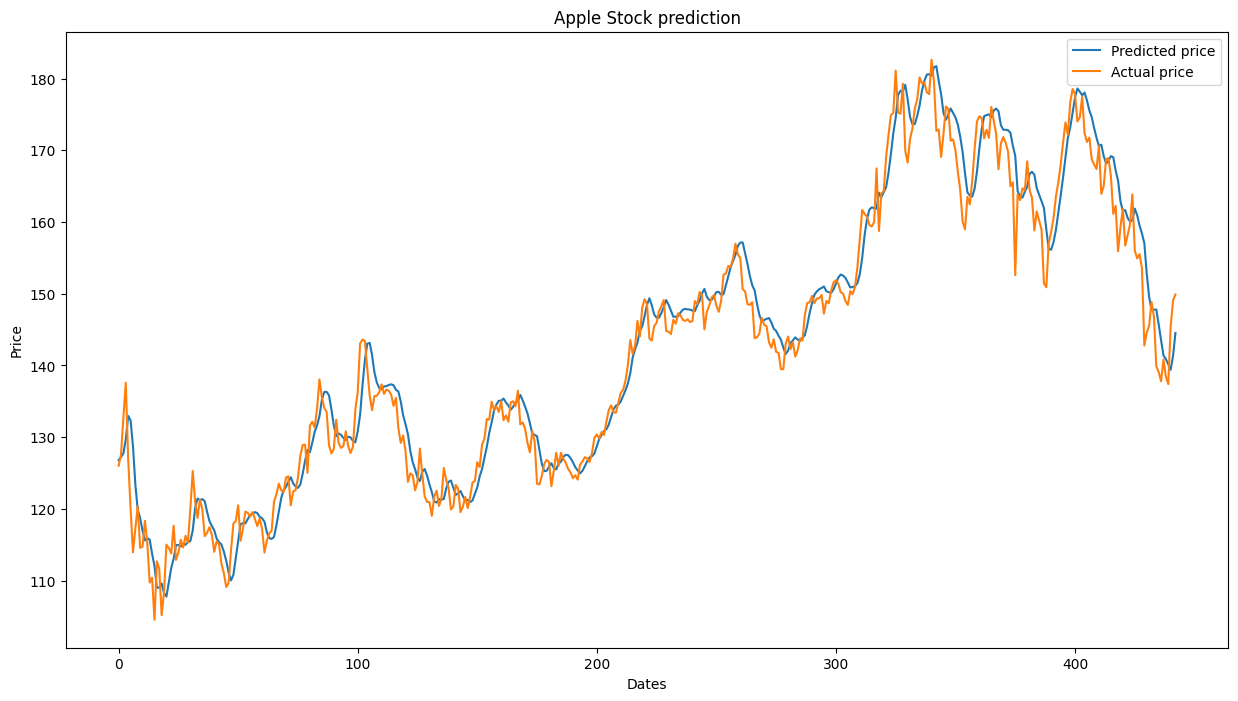

In [92]:

plt.figure(figsize=(15,8))
plt.plot(opening_price,label="Predicted price")
plt.plot(valid2,label='Actual price')
plt.title('Apple Stock prediction')
plt.xlabel("Dates")
plt.ylabel("Price")
plt.legend(loc="upper right")
plt.show()
